In [1]:
import numpy as np

from dipy.core.gradients import gradient_table
from dipy.data import get_fnames, default_sphere
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti

hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames('stanford_hardi')

data, affine = load_nifti(hardi_fname)

bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs)

/tmp/ipykernel_12738/1113508968.py:8: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames('stanford_hardi')
/tmp/ipykernel_12738/1113508968.py:13: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  gtab = gradient_table(bvals, bvecs)


In [2]:
from dipy.reconst.csdeconv import (auto_response_ssst,
                                   mask_for_response_ssst,
                                   response_from_mask_ssst)

response, ratio = auto_response_ssst(gtab, data, roi_radii=10, fa_thr=0.7)

In [3]:
mask = mask_for_response_ssst(gtab, data, roi_radii=10, fa_thr=0.7)
nvoxels = np.sum(mask)
print(nvoxels)

response, ratio = response_from_mask_ssst(gtab, data, mask)
print(response)
print(ratio)

1254
(array([0.00139919, 0.0003007 , 0.0003007 ]), np.float64(416.7372408293461))
0.21491283972217431


In [56]:
from dipy.viz import window, actor
from dipy.sims.voxel import single_tensor_odf, multi_tensor_odf
from IPython.display import Image
import io

# Enables/disables interactive visualization

scene = window.Scene()
evals = response[0]
evecs = np.array([[0, 1, 0], [0, 0, 1], [1, 0, 0]]).T


response_odf = single_tensor_odf(default_sphere.vertices, evals, evecs)
# transform our data from 1D to 4D
response_odf = response_odf[None, None, None, :]
response_actor = actor.odf_slicer(response_odf, sphere=default_sphere,
                                  colormap='plasma')
scene.add(response_actor)

# Save the scene into a file and display it in Jupyter

window.snapshot(scene, fname='scene.png', offscreen=True)
with open('scene.png', 'rb') as f:
    display(Image(f.read()))
    

/tmp/ipykernel_8605/2205312528.py:13: UserWarning: Pass ['evals', 'evecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  response_odf = single_tensor_odf(default_sphere.vertices, evals, evecs)


ValueError: Input must be 1- or 2-d.

In [14]:
import numpy as np
import scipy.special as sp
from scipy.integrate import quad
from scipy.linalg import lstsq
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Constants and Parameters
b = 1000  # b-value (s/mm^2)
lambda_stick = 0.001  # Stick diffusivity (mm^2/s)
lambda_ball = 0.003  # Ball diffusivity (mm^2/s)
f = .5  # Fractional anisotropy (FA)
mu = np.array([1, 0, 0])  # Stick orientation (unit vector)
lmax = 12  # Maximum SH order
n_directions = 100  # Number of gradient directions

# Generate gradient directions
phi = np.random.uniform(0, 2 * np.pi, n_directions)
theta = np.arccos(np.random.uniform(-1, 1, n_directions))
gradients = np.array([
    np.sin(theta) * np.cos(phi),
    np.sin(theta) * np.sin(phi),
    np.cos(theta)
]).T

# Ball-and-Stick Model Signal
def ball_and_stick_signal(b, g, f, mu, lambda_stick, lambda_ball):
    dot_product = np.dot(g, mu) ** 2
    stick_signal = np.exp(-lambda_stick * b * dot_product)
    ball_signal = np.exp(-lambda_ball * b)
    return f * stick_signal + (1 - f) * ball_signal

# Compute Signal
signals = np.array([
    ball_and_stick_signal(b, g, f, mu, lambda_stick, lambda_ball) for g in gradients
])

# Spherical Harmonic Basis
sh_coeffs = []
def spherical_harmonic_basis(l, m, theta, phi):
    return sp.sph_harm(m, l, phi, theta)

def fit_sh_coefficients(signals, gradients, lmax):
    # Construct spherical harmonic basis matrix
    sh_basis = []
    for g in gradients:
        theta = np.arccos(g[2])  # Polar angle
        phi = np.arctan2(g[1], g[0])  # Azimuthal angle
        row = []
        for l in range(0, lmax + 1, 2):
            for m in range(-l, l + 1):
                row.append(spherical_harmonic_basis(l, m, theta, phi).real)
        sh_basis.append(row)
    
    sh_basis = np.array(sh_basis)  # Convert to 2D array (n_directions x n_SH_terms)
    
    # Solve for SH coefficients using least squares
    coeffs, _, _, _ = lstsq(sh_basis, signals)
    return coeffs


# Fit SH Coefficients
sh_coeffs = fit_sh_coefficients(signals, gradients, lmax)

# Reconstruct FOD
n_plot_points = 500
phi_plot = np.linspace(0, 2 * np.pi, n_plot_points)
theta_plot = np.linspace(0, np.pi, n_plot_points)
phi_grid, theta_grid = np.meshgrid(phi_plot, theta_plot)

def reconstruct_fod(coeffs, lmax, theta_grid, phi_grid):
    fod = np.zeros(theta_grid.shape)
    coeff_idx = 0  # Index for accessing coefficients
    for l in range(0, lmax + 1, 2):
        for m in range(-l, l + 1):
            # Add contribution of each SH term to the FOD
            fod += coeffs[coeff_idx] * spherical_harmonic_basis(l, m, theta_grid, phi_grid).real
            coeff_idx += 1  # Increment index for each coefficient
    return fod

fod = reconstruct_fod(sh_coeffs, lmax, theta_grid, phi_grid)


/tmp/ipykernel_8605/2605711551.py:41: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  return sp.sph_harm(m, l, phi, theta)


In [20]:
# %matplotlib widget
# # Plot FOD
# x = fod * np.sin(theta_grid) * np.cos(phi_grid)
# y = fod * np.sin(theta_grid) * np.sin(phi_grid)
# z = fod * np.cos(theta_grid)

# fig = plt.figure(figsize=(10, 10))
# ax = fig.add_subplot(111, projection="3d")
# ax.plot_surface(x, y, z, rstride=5, cstride=5, alpha=0.7, edgecolor="k")
# ax.set_title("Reconstructed FOD")
# plt.show()


In [79]:
import numpy as np
from dipy.viz import window, actor
from dipy.data import get_sphere
from dipy.sims.voxel import single_tensor_odf
from IPython.display import Image
import io

# Simulate the Ball-and-Stick FOD
b = 1000  # b-value (s/mm^2)
lambda_stick = 0.01  # Stick diffusivity (mm^2/s)
lambda_ball = 0.001  # Ball diffusivity (mm^2/s)
f = 0.5  # Fractional anisotropy (FA)
mu = np.array([0, 1, 0])  # Stick orientation (unit vector)

# Generate sphere for directions
default_sphere = get_sphere('repulsion724')

# Signal computation function for Ball-and-Stick
def ball_and_stick(sphere_vertices, f, mu, lambda_stick, lambda_ball):
    odf = []
    for g in sphere_vertices:
        dot_product = np.dot(g, mu) ** 2
        stick_signal = np.exp(-lambda_stick * b * dot_product)
        ball_signal = np.exp(-lambda_ball * b)
        signal = f * stick_signal + (1 - f) * ball_signal
        odf.append(signal)
    return np.array(odf)


# Compute ODF for Ball-and-Stick model
response = ball_and_stick(default_sphere.vertices, f, mu, lambda_stick, lambda_ball)


/tmp/ipykernel_8605/2639104345.py:16: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  default_sphere = get_sphere('repulsion724')


In [80]:
from dipy.reconst.shm import sf_to_sh, sh_to_sf

sh_order = 8             # spherical harmonic order
reg = 1e-3               # small Tikhonov-like regularization

# Convert discrete sphere function to SH
response_sh = sf_to_sh(response, default_sphere, sh_order=sh_order, basis_type=None)
data_sh     = sf_to_sh(odf_data, default_sphere, sh_order=sh_order, basis_type=None)

# Naive SH-based deconvolution: dividing the data by the response
fodf_sh = data_sh / (response_sh + reg)

# Convert SH FOD back to discrete sphere
fodf = sh_to_sf(fodf_sh, default_sphere, sh_order=sh_order, basis_type=None)
fodf = np.clip(fodf, 0, None)  # optional: enforce non-negativity


/tmp/ipykernel_8605/1668252765.py:7: ArgsDeprecationWarning: "sh_order" was deprecated

* deprecated from version: 1.9
* Will raise <class 'dipy.utils.deprecator.ExpiredDeprecationError'> as of version: 2.0
* Use argument "sh_order_max" instead.
  response_sh = sf_to_sh(response, default_sphere, sh_order=sh_order, basis_type=None)


NameError: name 'odf_data' is not defined

In [57]:
import numpy as np
from dipy.viz import window, actor
from dipy.reconst.shm import sh_to_sf, sf_to_sh
from dipy.data import get_sphere
from dipy.sims.voxel import single_tensor_odf, multi_tensor_odf

# Parameters
b = 1000  # b-value (s/mm^2)
lambda_stick = 0.01  # Stick diffusivity (mm^2/s)
lambda_ball = 0.001  # Ball diffusivity (mm^2/s)
f = 0.5  # Fractional anisotropy (FA)
mu = np.array([0, 1, 0])  # Stick orientation (unit vector)

# Generate sphere for directions
default_sphere = get_sphere('repulsion724')

# Signal computation function for Ball-and-Stick
def ball_and_stick(sphere_vertices, f, mu, lambda_stick, lambda_ball):
    odf = []
    for g in sphere_vertices:
        dot_product = np.dot(g, mu) ** 2
        stick_signal = np.exp(-lambda_stick * b * dot_product)
        ball_signal = np.exp(-lambda_ball * b)
        signal = f * stick_signal + (1 - f) * ball_signal
        odf.append(signal)
    return np.array(odf)

# Compute ODF for Ball-and-Stick model
signal = ball_and_stick(default_sphere.vertices, f, mu, lambda_stick, lambda_ball)


# Fit to spherical harmonics (SH)
order = 16  # SH order, controls angular resolution
sh_coeffs = sf_to_sh(signal, default_sphere, sh_order=order, smooth=0.0)

# Convert SH back to signal for verification
fitted_signal = sh_to_sf(sh_coeffs, default_sphere, sh_order=order)


fitted_signal.shape

/tmp/ipykernel_8605/1866495688.py:15: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  default_sphere = get_sphere('repulsion724')
/tmp/ipykernel_8605/1866495688.py:34: ArgsDeprecationWarning: "sh_order" was deprecated

* deprecated from version: 1.9
* Will raise <class 'dipy.utils.deprecator.ExpiredDeprecationError'> as of version: 2.0
* Use argument "sh_order_max" instead.
  sh_coeffs = sf_to_sh(signal, default_sphere, sh_order=order, smooth=0.0)
/tmp/ipykernel_8605/1866495688.py:37: ArgsDeprecationWarning: "sh_order" was deprecated

* deprecated from version: 1.9
* Will raise <class 'dipy.utils.deprecator.ExpiredDeprecationError'> as of version: 2.0
* Use argument "sh_order_max" instead.
  fitted_signal = sh_to_sf(sh_coeffs, default_sphere, sh_order=order)


(724,)

/tmp/ipykernel_8605/4004783274.py:11: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  default_sphere = get_sphere('repulsion724')
/tmp/ipykernel_8605/4004783274.py:31: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(8, 8))


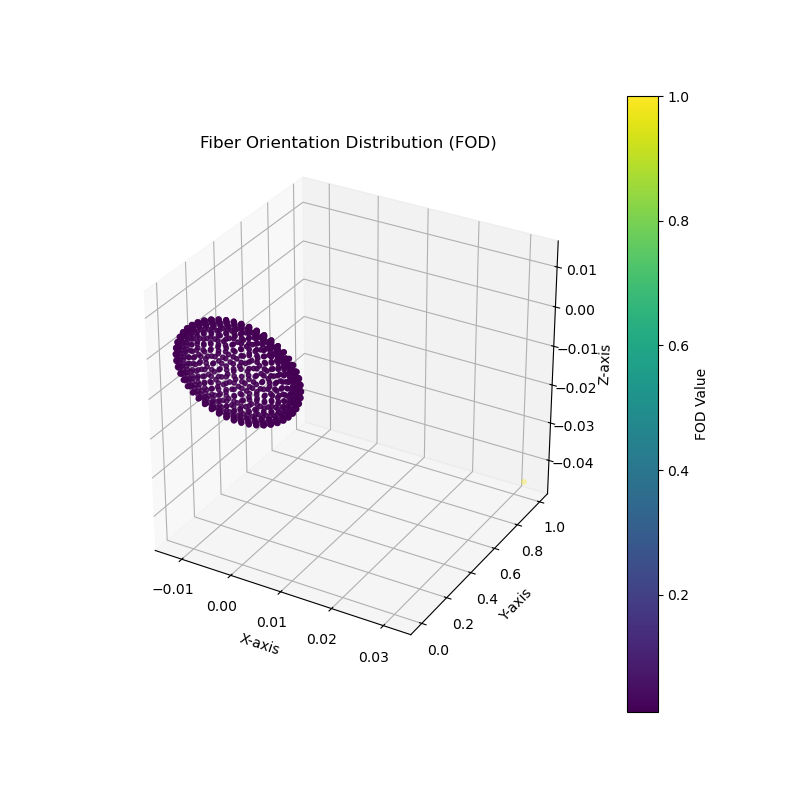

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from dipy.data import get_sphere

# Parameters
f = 0.1  # Fraction of anisotropic stick component
mu = np.array([0, 1, 0])  # Stick orientation (unit vector)
kappa = 0.1  # Concentration parameter for stick peak (Von Mises-Fisher distribution)

# Generate sphere for FOD visualization
default_sphere = get_sphere('repulsion724')

# Compute the isotropic ball component (uniform density)
def ball_density(sphere_vertices):
    return np.ones(len(sphere_vertices)) / len(sphere_vertices)

# Compute the anisotropic stick component (density only along mu)
def stick_density(sphere_vertices, mu):
    dot_products = np.dot(sphere_vertices, mu)
    density = np.zeros(len(sphere_vertices))
    density[np.argmax(dot_products)] = 1.0  # Assign all density to the direction closest to mu
    return density / np.sum(density)  # Normalize to sum to 1

# Combine ball and stick components to form the FOD
ball = ball_density(default_sphere.vertices)
stick = stick_density(default_sphere.vertices, mu)
fod = f * stick + (1 - f) * ball  # Weighted sum of components
fod /= np.max(fod)  # Normalize FOD for consistent scaling

# Plot the FOD as scaled points on the sphere
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Scale sphere vertices by the FOD values
x, y, z = default_sphere.vertices.T
radii = fod
x_scaled = x * radii
y_scaled = y * radii
z_scaled = z * radii

# Plot points instead of a triangular mesh
sc = ax.scatter(x_scaled, y_scaled, z_scaled, c=fod, cmap='viridis', s=10)
ax.set_box_aspect([1, 1, 1])  # Equal aspect ratio

# Add labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Fiber Orientation Distribution (FOD)')
plt.colorbar(sc, ax=ax, label='FOD Value')
plt.show()
